I'm continuing [my resolution to share more unfinished work](https://andreasthinks.me/posts/share-crappy-fiddles.html), so here's a finding from a project I'm still in the middle of.

A few weeks ago I built a classifier to detect AI coding tool users from public GitHub
commit history. The idea was simple: if AI tools change *how* developers code
(commit cadence, message length, structural patterns), those changes should be
detectable from public artefacts. The classifier hit AUC 0.94 and generalised across
tools — it was trained on Claude Code adopters and still scored Aider users at a
mean predicted probability of 0.73.

So I had a way to measure AI adoption at scale, without surveys or vendor telemetry.
I pointed it at 4,824 GitHub accounts spread across 53 countries to ask the
follow-up question:

> Do countries with higher AI adoption rates show higher developer productivity?

The honest answer turned out to be more interesting than I expected. It depends
entirely on which productivity metric you pick. And that, I think, is the actual
finding.


In [1]:
# | echo: false
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# Dark-friendly matplotlib style — the blog's CSS dark-plot filter inverts for light mode
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'savefig.facecolor':'#0d1117',
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'axes.titlecolor':  '#e6edf3',
    'xtick.color':      '#bdc4cd',
    'ytick.color':      '#bdc4cd',
    'axes.edgecolor':   '#3a4250',
    'grid.color':       '#2a313c',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'figure.dpi':       110,
    'savefig.dpi':      150,
    'font.size':        11,
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'legend.frameon':   False,
})

ACCENT  = '#7bfcca'   # primary
ACCENT2 = '#ff8b5e'   # contrast
NEUTRAL = '#888899'

DATA = Path("/home/avery/projects/ai_productivity_analysis/data")


In [2]:
# | echo: false
# Load adoption rates from the combined v1+v2+v3 population scrape
MIN_ACCOUNTS = 15
MIN_DEVS = 5

scores_all = pd.concat([
    pd.read_csv(DATA / f) if (DATA / f).exists() else pd.DataFrame()
    for f in ["population_scores.csv", "population_scores_v2.csv", "population_scores_v3.csv"]
], ignore_index=True).drop_duplicates(subset="login", keep="first")

country_adoption = (
    scores_all.groupby("country")
    .agg(mean_ai_score=("post_classifier_score", "mean"),
         n_accounts=("login", "count"))
    .reset_index()
)
country_adoption = country_adoption[country_adoption["n_accounts"] >= MIN_ACCOUNTS]
score_map = dict(zip(country_adoption["country"], country_adoption["mean_ai_score"]))

# Load panel
panel = pd.read_csv(DATA / "github_panel_flat.csv")
panel["year"] = panel["quarter"].str.extract(r"(\d{4})").astype(int)
panel["log_commits"] = np.log1p(panel["commits_per_dev"])
panel["log_prs"]     = np.log1p(panel["prs_per_dev"])
panel["log_events"]  = np.log1p(panel["total_events_per_dev"])
panel["pct_ai_users"] = panel.apply(
    lambda r: 0.0 if r["year"] < 2024 else score_map.get(r["country"], float("nan")),
    axis=1
)

panel_clean = panel.dropna(subset=["pct_ai_users"]).copy()
panel_clean = panel_clean[panel_clean["country"].isin(score_map.keys())]
panel_year = (
    panel_clean.groupby(["country", "year"])
    .agg(log_commits=("log_commits","mean"),
         log_prs=("log_prs","mean"),
         log_events=("log_events","mean"),
         pct_ai_users=("pct_ai_users","mean"),
         n_developers=("n_developers","sum"))
    .reset_index()
)
panel_year = panel_year[panel_year["n_developers"] >= MIN_DEVS]

cross24 = panel_year[panel_year["year"]==2024].dropna(
    subset=["pct_ai_users","log_commits","log_prs","log_events"]
).copy()

print(f"Loaded {len(scores_all):,} scored accounts across {len(country_adoption)} countries")
print(f"2024 cross-section: {len(cross24)} countries with >=15 scored accounts and >=5 panel devs")


Loaded 4,824 scored accounts across 46 countries
2024 cross-section: 31 countries with >=15 scored accounts and >=5 panel devs


## The classifier, briefly


The classifier is trained on 276 GitHub accounts: 74 confirmed AI adopters
(identified by `CLAUDE.md` files in their repos or `Co-Authored-By: Claude`
trailers in their commit history) and 202 controls (accounts with active commit
histories before *and* after late 2023, with zero AI markers). It uses 43
behavioural features — commit cadence, message length and structure, PR body
patterns, inter-commit timing — and explicitly *excludes* anything that would
let it cheat by matching the labelling artefacts.

Random Forest, 5-fold cross-validation, AUC 0.94. Strip out all the message-content
features and it still hits 0.91 on activity patterns alone. Test it on Aider users
— a tool it was never trained on — and they score a mean predicted probability of
0.73 vs 0.03 for controls. So whatever it's detecting, it's not Claude-specific
stylistic quirks. It's a general "this developer's behaviour looks AI-assisted"
signal.

If you want the methodology in detail, [the paper is here](../../papers/ai-productivity/).
For the rest of this post I'll just treat the classifier as a black box that gives
me a probability per account, and we'll talk about what those probabilities tell us.


## The country-level puzzle


With per-account AI scores in hand, the obvious next move is to aggregate them up.
Take the 4,824 scored accounts, group them by country, take the mean classifier
score per country, and you get an "AI adoption rate" for each country. This is
the country-level independent variable.

For the dependent variable, I have a panel of GitHub Archive data from 2022–2024
giving me, per country per quarter, the number of commits per active developer
and the number of pull requests per active developer. These are the two natural
output measures.

Both metrics tell you about developer activity. Both are normalised per developer
to control for ecosystem size. Both are commonly used in the empirical
productivity literature on software development. If AI tools are increasing
developer productivity, you'd expect both to go up in countries with higher AI
adoption.

What I actually found is that they go in opposite directions.


## The plot that started this post


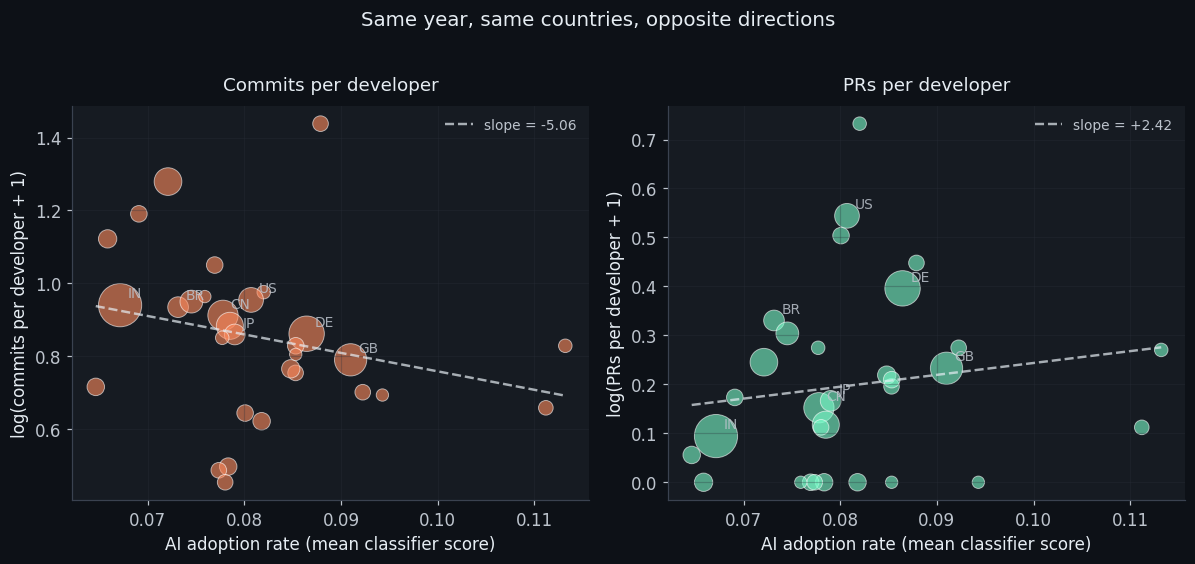

In [3]:
# | echo: false
# | classes: dark-plot
# | fig-cap: "2024 cross-section: each circle is a country, sized by number of developers in the GH Archive panel. The IV is the mean classifier score for accounts with parseable locations in that country (>=15 accounts each). Lines are unweighted OLS fits."
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True)

specs = [
    (axes[0], "log_commits", "log(commits per developer + 1)", "Commits per developer", ACCENT2),
    (axes[1], "log_prs",     "log(PRs per developer + 1)",     "PRs per developer",     ACCENT),
]

for ax, dv, ylabel, title, color in specs:
    sizes = (cross24["n_developers"] / cross24["n_developers"].max() * 800).clip(lower=40)
    ax.scatter(cross24["pct_ai_users"], cross24[dv],
               s=sizes, alpha=0.6, color=color,
               edgecolor='white', linewidth=0.6)

    # Linear fit
    z = np.polyfit(cross24["pct_ai_users"], cross24[dv], 1)
    xs = np.linspace(cross24["pct_ai_users"].min(), cross24["pct_ai_users"].max(), 50)
    ax.plot(xs, np.poly1d(z)(xs), color='#e6edf3', linewidth=1.6, linestyle='--', alpha=0.7,
            label=f"slope = {z[0]:+.2f}")

    # Annotate a few interesting countries
    interesting = ["US", "IN", "GB", "DE", "BR", "CN", "JP"]
    for _, row in cross24.iterrows():
        if row["country"] in interesting:
            ax.annotate(row["country"],
                        xy=(row["pct_ai_users"], row[dv]),
                        xytext=(5, 5), textcoords="offset points",
                        fontsize=9, color='#bdc4cd', alpha=0.85)

    ax.set_xlabel("AI adoption rate (mean classifier score)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, color='#e6edf3', pad=10, fontsize=12)
    ax.legend(loc='best', fontsize=9, labelcolor='#bdc4cd')

plt.suptitle("Same year, same countries, opposite directions", color='#e6edf3', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/dv_split.png", bbox_inches='tight', facecolor='#0d1117')
plt.show()


On the left: commits per developer in 2024, plotted against the country's mean AI
adoption rate. Higher AI adoption, lower commits. The slope is negative, the dashed
line tilts down.

On the right: pull requests per developer, same countries, same year. The slope
is *slightly positive*. Statistically indistinguishable from zero, but definitely
not negative.

Same developers. Same year. Same AI adoption measure. Two reasonable productivity
metrics, going in opposite directions.

This isn't an artefact of one weird specification. I ran the regression with
country and year fixed effects, weighted by the number of developers, with and
without a pre-period control, swapping the IV for a threshold-based version
(fraction of accounts scoring above 0.5) and a median version, and as a clean
2024 OLS cross-section. The commits result keeps coming back negative
(coefficients between −5 and −8 across specifications). The PR result keeps
coming back as a precise null (coefficient around +1, standard error around 4).


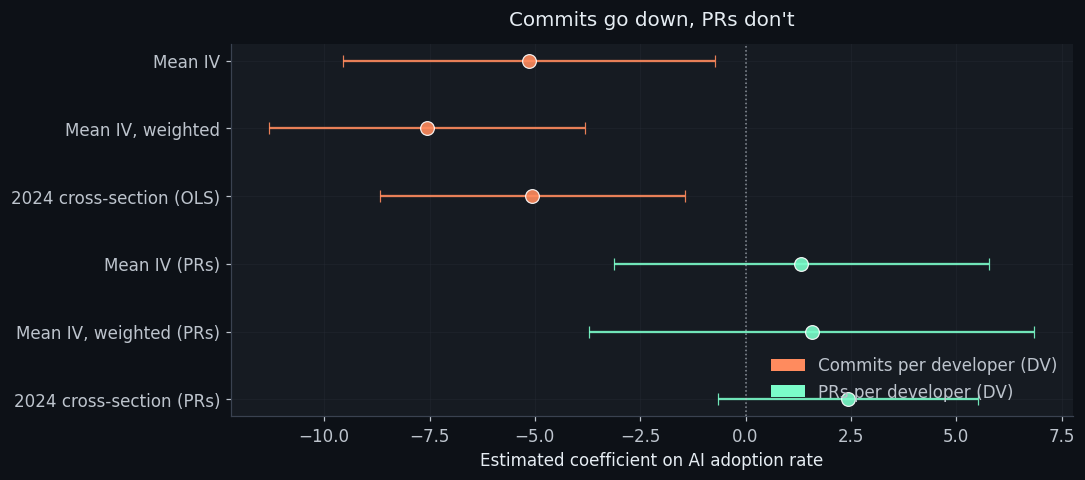

In [4]:
# | echo: false
# | classes: dark-plot
# | fig-cap: "Coefficient on the country-level AI adoption rate across specifications. Whiskers are ±1 SE. The vertical line at zero separates negative from positive estimates. Note that the commits estimates are clustered on the negative side, the PR estimates straddle zero."

specs_list = [
    # (label, dv, formula, weighted)
    ("Mean IV",                  "log_commits", "log_commits ~ pct_ai_users + EntityEffects + TimeEffects", False),
    ("Mean IV, weighted",        "log_commits", "log_commits ~ pct_ai_users + EntityEffects + TimeEffects", True),
    ("2024 cross-section (OLS)", "log_commits", None, False),
    ("Mean IV (PRs)",            "log_prs",     "log_prs ~ pct_ai_users + EntityEffects + TimeEffects", False),
    ("Mean IV, weighted (PRs)",  "log_prs",     "log_prs ~ pct_ai_users + EntityEffects + TimeEffects", True),
    ("2024 cross-section (PRs)", "log_prs",     None, False),
]

results = []
for label, dv, formula, weighted in specs_list:
    if formula is None:
        c24 = cross24.dropna(subset=[dv])
        m = smf.ols(f"{dv} ~ pct_ai_users", data=c24).fit()
        results.append((label, dv, float(m.params['pct_ai_users']), float(m.bse['pct_ai_users']), int(m.nobs)))
    else:
        df2 = panel_year.set_index(["country","year"]).copy()
        if weighted:
            mod = PanelOLS.from_formula(formula, data=df2, drop_absorbed=True, weights=df2[["n_developers"]])
        else:
            mod = PanelOLS.from_formula(formula, data=df2, drop_absorbed=True)
        res = mod.fit(cov_type="clustered", cluster_entity=True)
        results.append((label, dv, float(res.params['pct_ai_users']), float(res.std_errors['pct_ai_users']), int(res.nobs)))

# Plot
fig, ax = plt.subplots(figsize=(10, 4.5))
y_positions = list(range(len(results)))
labels = [r[0] for r in results]
coefs  = [r[2] for r in results]
ses    = [r[3] for r in results]
colors = [ACCENT2 if r[1]=="log_commits" else ACCENT for r in results]

for y, c, s, col in zip(y_positions, coefs, ses, colors):
    ax.errorbar(c, y, xerr=s, fmt='o', color=col, capsize=4,
                markersize=9, markeredgecolor='white', markeredgewidth=0.8,
                elinewidth=1.5, alpha=0.9)

ax.axvline(0, color='#bdc4cd', linewidth=1, linestyle=':', alpha=0.7)
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Estimated coefficient on AI adoption rate")
ax.invert_yaxis()
ax.set_title("Commits go down, PRs don't", color='#e6edf3', pad=12, fontsize=13)

# Legend swatches
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=ACCENT2, label='Commits per developer (DV)'),
    Patch(facecolor=ACCENT,  label='PRs per developer (DV)'),
]
ax.legend(handles=legend_handles, loc='lower right', labelcolor='#bdc4cd')

plt.tight_layout()
plt.savefig("figures/coefficient_plot.png", bbox_inches='tight', facecolor='#0d1117')
plt.show()


## Three readings of the same data


You can tell at least three stories here. I find one of them most plausible, but
the data don't let me prove any of them, so let me lay them out and you can
make your own choice.

### 1. AI tools change the shape of commits, not the amount of work

This is the reading I find most compelling. AI coding assistants change *how*
developers commit, not how much they ship. They encourage workflows where you
work conversationally with the tool through a longer session, then commit the
result as a single coherent change. Squash-merge habits get reinforced. Each
commit covers more ground, has a longer and more structured message, and
represents more of what would previously have been three or four separate "wip"
commits.

If that's true, then `commits per developer` isn't a productivity metric. It's a
*commit granularity* metric in disguise. Countries where AI adoption is higher
ship the same amount of code, but in fewer, larger commits. The negative
coefficient on commits is a real behavioural shift that has nothing to do with
output going down.

The PR per developer null is consistent with this: PR cadence is driven by
feature scope, not commit cadence. If you're shipping the same features but in
fewer commits, your PR rate doesn't change.

This story is also consistent with what the classifier itself was trained to
detect — longer, more structured commit messages. The thing that makes a
developer "look AI-adopted" to the model is the same thing that drives the
commits-per-developer coefficient negative. Mechanism and measurement are
plausibly aligned.

### 2. The classifier is picking up something other than AI adoption

This one I worry about. A pre-period placebo test on the training data showed
that 6 of 8 features differ significantly between confirmed AI adopters and
controls *before* AI tools existed in their current form. The classifier captures
some combination of "uses AI tools" and "is the kind of careful, conscientious
developer who would later go on to use AI tools." Sample selection.

If countries differ in their proportion of careful-vs-fast developers, the
classifier-derived adoption rate is partly measuring that. And careful developers
might commit less frequently per unit of work for reasons that have nothing to do
with AI. The negative coefficient on commits might just be reflecting the
distribution of developer styles across countries.

I tried to address this with a baseline pre-period control in the regression. It
didn't help — the control is fully absorbed by the country fixed effects, so it
contributes no useful variation. So this confound remains genuinely possible.

### 3. AI tools really do slow individual commits down

There's a recent randomised trial by [METR](https://metr.org/) on experienced
open-source developers working on mature codebases. They expected AI tools to
speed them up by ~24%. The actual measured effect was a *19% slowdown*. The
authors' analysis of screen recordings suggested the tax came from prompt
formulation, output review, and context-loading on complex codebases.

If that mechanism applies more broadly, then in countries with higher AI
adoption, individual commits genuinely take longer (more time per commit
reviewing AI output) without changing what gets shipped overall. PR cadence
is unaffected because PRs aggregate over multiple commits. Commits per
developer goes down because each commit is more expensive in developer time.

This is a less appealing story for me than the granularity one — the METR
finding is on a specific population (experienced devs, mature codebases) and
the cleaner experimental literature (Peng et al., Demirer et al.) finds
substantial *speedups* in more representative samples. But it's a story the
data is consistent with, and it would be intellectually dishonest to dismiss it.


## What I think this means for the literature


There's a growing body of empirical work on AI tool adoption and developer
productivity. Most of it uses commit-based outcomes — count of commits, code
churn, things you can extract from git logs. If the granularity story is right,
that's a problem. A negative coefficient on commits per developer in your panel
might be telling you that your treated developers got *more efficient*, not less,
and you're measuring the wrong thing.

I don't think this invalidates the existing findings. The randomised experiments
that measure task completion time are largely robust to this — they're not
counting commits, they're counting whether the task got done. The observational
studies that use commit counts are more exposed.

If you're designing a future study in this space, I'd suggest:

- Use task-level outcomes if you can get them. PR merge rate, build success rate,
  feature ship time. These are downstream of commit cadence.
- If you must use commit-based outcomes, report PR-based ones alongside as a
  diagnostic. If they diverge in sign, you're probably looking at a granularity
  shift.
- Treat lines-changed and code volume metrics with the same suspicion. AI may
  encourage longer, more deliberate commits — those will look like more code per
  commit even if the underlying output is the same.

For my paper version of this analysis (which I'm writing alongside this post),
I'm reporting the commits/PRs split as the central robustness finding and being
explicit that the granularity hypothesis is a *plausible reading* of the
divergence, not a proven mechanism.


## Where I'm less sure


A handful of things that should temper the confidence with which this is read:

- **The 2024 cross-section is thin.** 31 countries, with AI adoption rates ranging
  from about 6% to 11%. That's not a lot of identifying variation, and a
  permutation placebo says the negative commits coefficient sits at the 15th
  percentile of the random-shuffle null. Not exonerated, but not a smoking gun
  either.
- **The IV is structurally a 2024 cross-section.** The panel framing (country and
  year fixed effects) is honest about this — there's no within-country variation
  in adoption before 2024 in my measure. The "panel regression" identifies off
  cross-country differences in 2024.
- **The classifier-as-IV inherits the conscientiousness confound.** I can't fully
  separate "this country has more AI adopters" from "this country has more
  developers whose behaviour looks the way AI adopters' behaviour looks."
- **GitHub Archive samples are noisy.** Median country-year cell has 2 located
  developers. Most of my measurement noise lives here.
- **The classifier is single-tool trained.** Generalises to Aider, but doesn't
  necessarily catch users of inline-only Copilot or other tools that leave less
  of a behavioural fingerprint.

The right move for me now is two-fold. I'm writing up the formal paper version
(more careful, more caveated, robustness battery in tables), which will live
[over here](../../papers/ai-productivity/) when it's done. And I'm thinking about
what a follow-up study would look like with cleaner identification — probably
exploiting the staggered availability of specific tools by country, with
task-level outcomes from CI build data rather than commit counts.

If you have a take on the granularity hypothesis, or you've seen this pattern
in your own data, I'd love to hear it. The repo for the analysis is
[here on GitHub](https://github.com/AndreasThinks/ai_productivity_analysis).

---

*Thanks to [Avery](https://andreasthinks.me/about.html#how-i-work-with-ai) for doing most of the actual work on this — including the painful bits like the rate-limit retry-trap diagnosis and the 14-spec robustness battery.*
